In [1]:
import pandas as pd
from Database.DB_reader import Database
from Database.Timescale.utils import get_trades_data

# Swing Data Feature Engineering and Target Calculation
This notebook fetches, merges, and processes swing-related predictor data and trade data for DEM1 15min candles, and prepares features and targets for modeling.

In [2]:
db = Database('timescaledb')

In [3]:
conn = db.connection_string

In [4]:
# Cell 5: Fetch each predictor individually and merge as requested

import pandas as pd

# Define predictor groups and their corresponding names
predictor_groups = {
    'macd': 'macd_macd_dem1_candles_5min_params_12_26_9',
    'macd_hist': 'macd_hist_dem1_candles_5min_params_12_26_9',
    'atr': 'atr_dem1_candles_15min_lookback_21',
    'swing_high': 'swing_high_dem1_candles_15min',
    'swing_low': 'swing_low_dem1_candles_15min'
}

dfs = {}

for group, pred_name in predictor_groups.items():
    query = f"""
    SELECT 
        ede.datetime, 
        ede.nanotime, 
        ede.tradeid, 
        ede.pred_value AS {group}
    FROM 
        experimental_dataset_entries ede
    JOIN 
        experimental_predictors ep 
        ON ede.pred_id = ep.pred_id
    WHERE 
        ep.pred_name = '{pred_name}'
        AND ep.author = 'MatejKrajcovic'
        AND ede.datetime >= '2025-01-01'
        AND ede.datetime < '2025-01-29'
    """
    dfs[group] = pd.read_sql(query, conn)

# Merge all DataFrames on ['datetime', 'nanotime', 'tradeid']
from functools import reduce

merged_df = reduce(
    lambda left, right: pd.merge(left, right, on=['datetime', 'nanotime', 'tradeid'], how='outer'),
    dfs.values()
)

In [5]:
df_trades = get_trades_data('dem1', "2025-01-01", "2025-01-29")

Connected to the database timescaledb
Disconnected from the database timescaledb
'Index' object has no attribute 'microsecond'
Connected to the database timescaledb
Disconnected from the database timescaledb
'Index' object has no attribute 'microsecond'
Connected to the database timescaledb


C:\Users\krajcovic\Documents\GitHub\EnergyTrading\Python\Database\TPData.py:571: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  df_out.index = df_out.index + pd.to_timedelta(df_data.loc[~idx, 'nanotime'].astype(float), unit='ns')


Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the databa

In [6]:
df_raw = pd.merge(
    merged_df, df_trades, on='tradeid', how='outer', suffixes=('', '_trade'))

In [7]:
df = df_raw.set_index('datetime').sort_index().ffill().dropna().copy()

In [8]:
df['macd_norm'] = df['macd']/df['atr']
df['macd_hist_norm'] = df['macd_hist']/df['atr']
df['price_range'] = df['swing_high'] - df['swing_low']
df['price_position'] = (df['price'] - df['swing_low']) / df['price_range']

In [9]:
from src.data_processing import target_calculator

In [10]:
fut_trades = 500
targets = target_calculator.compute_future_trade_targets(
    df.rename(columns={'atr':'atr_value'}),fut_trades)

In [11]:
targets.columns

Index(['tradeid', 'current_price', 'current_atr', 'n_future_trades',
       'target_mean', 'target_median', 'target_p25', 'target_p75',
       'future_trade_prices', 'min_future_price', 'max_future_price',
       'price_range'],
      dtype='object')

In [12]:
targets = targets.loc[targets['n_future_trades'] == fut_trades].copy()

In [13]:
targets['current_price'].iloc[1:fut_trades+1].values == targets['future_trade_prices'].iloc[0]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [14]:
df = df.reset_index().merge(
    targets.reset_index()[['tradeid', 'target_mean', 'target_median']],
    on='tradeid',
    how='left'
).dropna()

In [15]:
from src.models.bias_classifier import BiasClassifier

In [16]:
classifier = BiasClassifier()
classifier.get_threshold_info()

{'macd_line_thresholds': {'lower': -0.1, 'upper': 0.1},
 'macd_histogram_thresholds': {'lower': -0.05, 'upper': 0.05},
 'bias_classes': ['Strong Bearish',
  'Bearish',
  'Neutral',
  'Bullish',
  'Strong Bullish'],
 'numeric_encoding': {'Strong Bearish': -2,
  'Bearish': -1,
  'Neutral': 0,
  'Bullish': 1,
  'Strong Bullish': 2}}

In [17]:
classified_data = classifier.predict(
        df,
        macd_line_column='macd_norm',
        macd_histogram_column='macd_hist_norm'
    )

In [18]:
classified_data.columns

Index(['datetime', 'nanotime', 'tradeid', 'macd', 'macd_hist', 'atr',
       'swing_high', 'swing_low', 'price', 'volume', 'action', 'broker_id',
       'own_trades', 'macd_norm', 'macd_hist_norm', 'price_range',
       'price_position', 'target_mean', 'target_median', 'macd_line_class',
       'macd_histogram_class', 'bias_classification', 'bias_numeric'],
      dtype='object')

# Backtest
This section will contain backtesting logic and results for the processed swing data.

Position classifier

"Logic for creating thresholds: There are two thresholds buy threshold/sell threshold. There are 5 bias classes - Strong Bullish, Bullish, Neutral, Bearish, Strong Bearish. Neutral class will have buy threshold X and sell threshold S, Bullish class will then have buy threshold X and sell threshold S + a (S < (S+a)). Stong Bullish class will have buy threshold B + c (B < (B+c)) and None sell threshold. Bearish class will have buy threshold B - e (B > (B-e)) and sell threshold S. Strong Bearish class will have no buy threshold and sell threshold S -g (S > (S-g)). So buy threshold for Neutral class = buy threshold for Bullish class < buy threshold String BUllish class. Sell threshold for Neutral class = sell threshold for Bearish class > sell threshold for String Bearish class. The alogrithm must intake thresholds for each bias (6 thresholds) and decide ig the price_position is within the threshold. For buy threshold price_poisiton < buy threshold (for given bias class) = Long/1. For sell threshold price_position > sell threshold (for given bias class) = Short/-1. ",


In [19]:
classified_data = classified_data.loc[classified_data['datetime']<pd.to_datetime('2025-01-29')].copy()

In [20]:
classified_data.head()

,datetime,nanotime,tradeid,macd,macd_hist,atr,swing_high,swing_low,price,volume,...,macd_norm,macd_hist_norm,price_range,price_position,target_mean,target_median,macd_line_class,macd_histogram_class,bias_classification,bias_numeric
0,2025-01-03 12:00:31,102380121.0,Eurex T7/DEBM022025-20250103/3322/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.204893,-0.302943,2.64,0.647727,-0.033722,0.0,Bearish,Bearish,Strong Bearish,-2
1,2025-01-03 12:00:31,595000000.0,16679521,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.204893,-0.302943,2.64,0.647727,-0.033687,0.0,Bearish,Bearish,Strong Bearish,-2
2,2025-01-03 12:00:31,102380121.0,Eurex T7/F7BM022025-20250103/3322/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.204893,-0.302943,2.64,0.647727,-0.033653,0.0,Bearish,Bearish,Strong Bearish,-2
3,2025-01-03 12:00:39,0.0,8064721,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.204893,-0.302943,2.64,0.647727,-0.033069,0.0,Bearish,Bearish,Strong Bearish,-2
4,2025-01-03 12:00:39,874445084.0,Eurex T7/DEBQ042025-20250103/3324/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.204893,-0.302943,2.64,0.647727,-0.033447,0.0,Bearish,Bearish,Strong Bearish,-2


In [21]:
classified_data['price_position'].describe()

count    358371.000000
mean          0.463801
std           0.443020
min          -3.871429
25%           0.189655
50%           0.444444
75%           0.708661
max           4.188525
Name: price_position, dtype: float64

<Axes: >

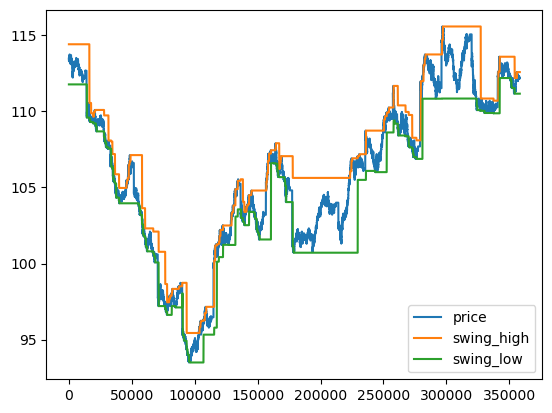

In [22]:
classified_data[['price', 'swing_high', 'swing_low']].plot()

In [23]:
# Position classifier logic based on bias class and thresholds
# Define thresholds for each bias class (example values, adjust as needed)
thresholds = {
    'Strong Bullish': {'buy': 0.35, 'sell': None},
    'Bullish': {'buy': 0.2, 'sell': 0.9},
    'Neutral': {'buy': 0.2, 'sell': 0.9},
    'Bearish': {'buy': 0.1, 'sell': 0.8},
    'Strong Bearish': {'buy': None, 'sell': 0.65}
}

# Function to assign position based on bias and price_position

def assign_position(row):
    bias = row['bias_classification']  # assumes classified_data has a 'bias_class' column
    price_pos = row['price_position']
    th = thresholds.get(bias, {'buy': None, 'sell': None})
    if th['buy'] is not None and price_pos < th['buy']:
        return 1  # Long
    elif th['sell'] is not None and price_pos > th['sell']:
        return -1  # Short
    else:
        return 0  # No position

classified_data['position_signal'] = classified_data.apply(assign_position, axis=1)
classified_data[['bias_classification', 'price_position', 'position_signal']].head()

classified_data[['position_signal', 'target_mean']].groupby('position_signal').mean()

,target_mean
position_signal,
-1,-0.049774
0,0.029457
1,-0.006011


In [24]:
import seaborn as sns

<Axes: xlabel='price_position', ylabel='target_mean'>

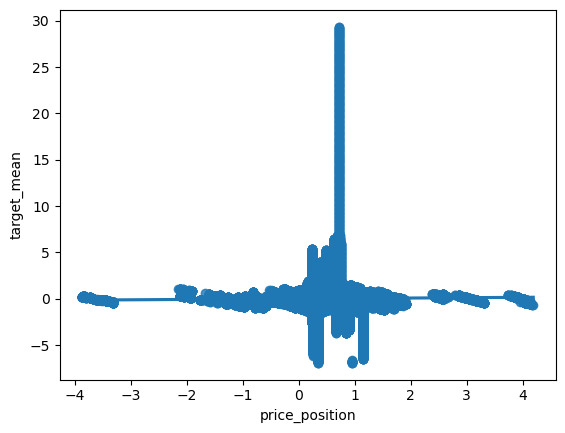

In [25]:
sns.regplot(data=classified_data[['price_position', 'target_mean']],x='price_position', y='target_mean')

In [26]:
import itertools
import pandas as pd

# Copy classified_data to a new DataFrame
df_signals = classified_data.copy()

# Define threshold grid (3 options for each threshold)
buy_bullish_neutral_options = [0.15, 0.2, 0.25]
buy_strong_bullish_options = [0.3, 0.35, 0.4]
sell_bearish_neutral_options = [0.7, 0.8, 0.9]
sell_strong_bearish_options = [0.5, 0.6, 0.7]

# For each combination, compute position signals and add as new columns
for buy_bn, buy_sb, sell_bn, sell_sb in itertools.product(
        buy_bullish_neutral_options, buy_strong_bullish_options,
        sell_bearish_neutral_options, sell_strong_bearish_options):
    thresholds_grid = {
        'Strong Bullish': {'buy': buy_sb, 'sell': None},
        'Bullish': {'buy': buy_bn, 'sell': sell_bn},
        'Neutral': {'buy': buy_bn, 'sell': sell_bn},
        'Bearish': {'buy': 0.1, 'sell': sell_bn},
        'Strong Bearish': {'buy': None, 'sell': sell_sb}
    }
    def assign_position(row):
        bias = row['bias_classification']
        price_pos = row['price_position']
        th = thresholds_grid.get(bias, {'buy': None, 'sell': None})
        if th['buy'] is not None and price_pos < th['buy']:
            return 1  # Long
        elif th['sell'] is not None and price_pos > th['sell']:
            return -1  # Short
        else:
            return 0  # No position
    col_name = f"pos_bbn{buy_bn}_bsb{buy_sb}_sbn{sell_bn}_ssb{sell_sb}"
    df_signals[col_name] = df_signals.apply(assign_position, axis=1)

df_signals.head()

,datetime,nanotime,tradeid,macd,macd_hist,atr,swing_high,swing_low,price,volume,...,pos_bbn0.25_bsb0.35_sbn0.9_ssb0.7,pos_bbn0.25_bsb0.4_sbn0.7_ssb0.5,pos_bbn0.25_bsb0.4_sbn0.7_ssb0.6,pos_bbn0.25_bsb0.4_sbn0.7_ssb0.7,pos_bbn0.25_bsb0.4_sbn0.8_ssb0.5,pos_bbn0.25_bsb0.4_sbn0.8_ssb0.6,pos_bbn0.25_bsb0.4_sbn0.8_ssb0.7,pos_bbn0.25_bsb0.4_sbn0.9_ssb0.5,pos_bbn0.25_bsb0.4_sbn0.9_ssb0.6,pos_bbn0.25_bsb0.4_sbn0.9_ssb0.7
0,2025-01-03 12:00:31,102380121.0,Eurex T7/DEBM022025-20250103/3322/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,0,-1,-1,0,-1,-1,0,-1,-1,0
1,2025-01-03 12:00:31,595000000.0,16679521,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,0,-1,-1,0,-1,-1,0,-1,-1,0
2,2025-01-03 12:00:31,102380121.0,Eurex T7/F7BM022025-20250103/3322/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,0,-1,-1,0,-1,-1,0,-1,-1,0
3,2025-01-03 12:00:39,0.0,8064721,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,0,-1,-1,0,-1,-1,0,-1,-1,0
4,2025-01-03 12:00:39,874445084.0,Eurex T7/DEBQ042025-20250103/3324/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,0,-1,-1,0,-1,-1,0,-1,-1,0


In [28]:
classified_data

,datetime,nanotime,tradeid,macd,macd_hist,atr,swing_high,swing_low,price,volume,...,macd_hist_norm,price_range,price_position,target_mean,target_median,macd_line_class,macd_histogram_class,bias_classification,bias_numeric,position_signal
0,2025-01-03 12:00:31,102380121.0,Eurex T7/DEBM022025-20250103/3322/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.302943,2.64,0.647727,-0.033722,0.000000,Bearish,Bearish,Strong Bearish,-2,0
1,2025-01-03 12:00:31,595000000.0,16679521,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.302943,2.64,0.647727,-0.033687,0.000000,Bearish,Bearish,Strong Bearish,-2,0
2,2025-01-03 12:00:31,102380121.0,Eurex T7/F7BM022025-20250103/3322/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.302943,2.64,0.647727,-0.033653,0.000000,Bearish,Bearish,Strong Bearish,-2,0
3,2025-01-03 12:00:39,0.0,8064721,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.302943,2.64,0.647727,-0.033069,0.000000,Bearish,Bearish,Strong Bearish,-2,0
4,2025-01-03 12:00:39,874445084.0,Eurex T7/DEBQ042025-20250103/3324/1,-0.11921,-0.176258,0.581818,114.42,111.78,113.49,1.0,...,-0.302943,2.64,0.647727,-0.033447,0.000000,Bearish,Bearish,Strong Bearish,-2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358366,2025-01-28 18:39:04,234000000.0,16918571,0.08147,0.071835,0.417273,112.59,111.17,112.19,1.0,...,0.172152,1.42,0.718310,29.138305,29.309368,Bullish,Bullish,Strong Bullish,2,0
358367,2025-01-28 18:43:18,632000000.0,16918574,0.08147,0.071835,0.417273,112.59,111.17,112.19,1.0,...,0.172152,1.42,0.718310,29.192946,29.309368,Bullish,Bullish,Strong Bullish,2,0
358368,2025-01-28 18:53:58,34000000.0,16918579,0.08147,0.071835,0.417273,112.59,111.17,112.19,1.0,...,0.172152,1.42,0.718310,29.247490,29.309368,Bullish,Bullish,Strong Bullish,2,0
358369,2025-01-28 18:54:00,378000000.0,16918580,0.08147,0.071835,0.417273,112.59,111.17,112.19,1.0,...,0.172152,1.42,0.718310,29.301987,29.309368,Bullish,Bullish,Strong Bullish,2,0


Text(0, 0.5, 'Target Mean')

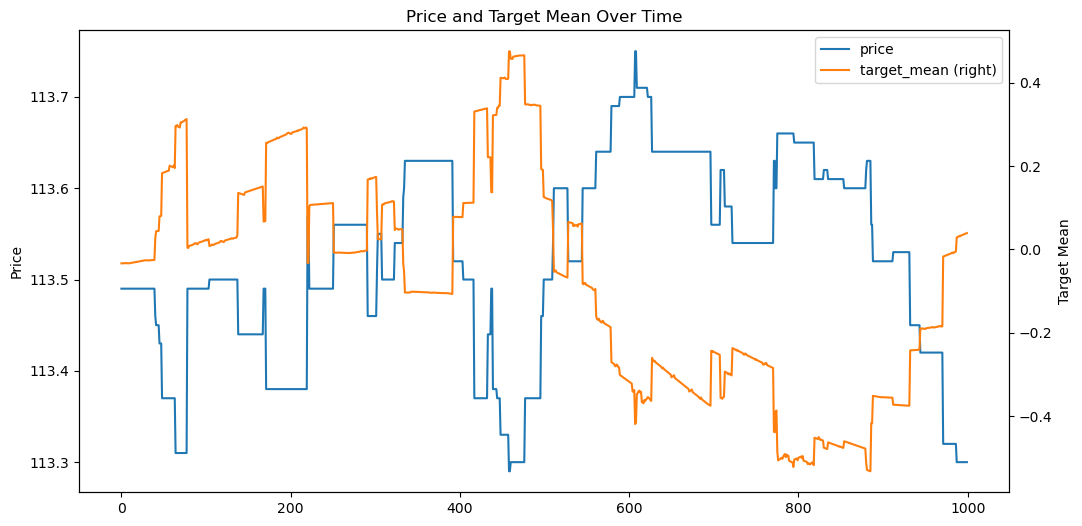

In [29]:
ax = classified_data[['price', 'target_mean']].iloc[:1000].plot(figsize=(12, 6), secondary_y='target_mean')
ax.set_title('Price and Target Mean Over Time')
ax.set_ylabel('Price')
ax.right_ax.set_ylabel('Target Mean')

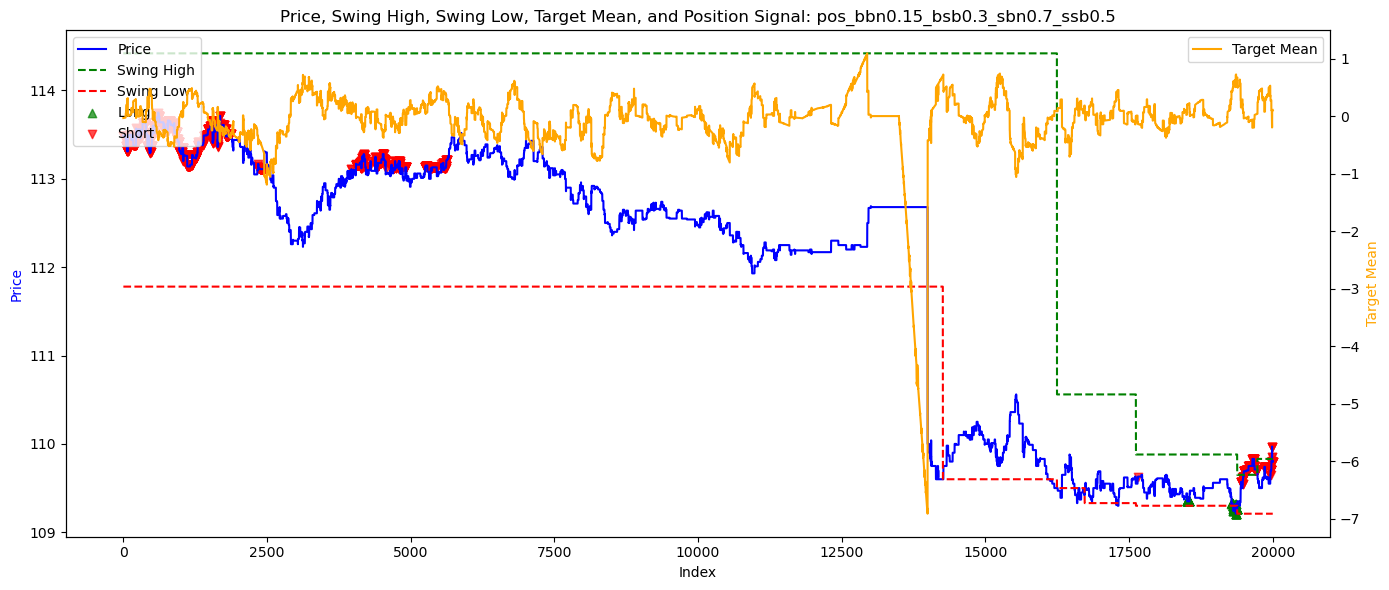

In [30]:
import matplotlib.pyplot as plt

# Option to set length of df to plot
plot_len = 20000  # Set this to desired number of rows to plot

# Get all position signal columns (those starting with 'pos_bbn')
pos_cols = [col for col in df_signals.columns if col.startswith('pos_bbn')]

for col in pos_cols[:1]:
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()
    idx = df_signals.index[:plot_len]
    ax1.plot(idx, df_signals['price'].iloc[:plot_len], color='blue', label='Price')
    ax1.plot(idx, df_signals['swing_high'].iloc[:plot_len], color='green', linestyle='--', label='Swing High')
    ax1.plot(idx, df_signals['swing_low'].iloc[:plot_len], color='red', linestyle='--', label='Swing Low')
    ax2.plot(idx, df_signals['target_mean'].iloc[:plot_len], color='orange', label='Target Mean')
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Price', color='blue')
    ax2.set_ylabel('Target Mean', color='orange')
    # Overlay position signal as points on the price chart
    pos_signal = df_signals[col].iloc[:plot_len]
    long_idx = idx[pos_signal == 1]
    short_idx = idx[pos_signal == -1]
    ax1.scatter(long_idx, df_signals.loc[long_idx, 'price'], color='green', marker='^', label='Long', alpha=0.7)
    ax1.scatter(short_idx, df_signals.loc[short_idx, 'price'], color='red', marker='v', label='Short', alpha=0.7)
    plt.title(f'Price, Swing High, Swing Low, Target Mean, and Position Signal: {col}')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

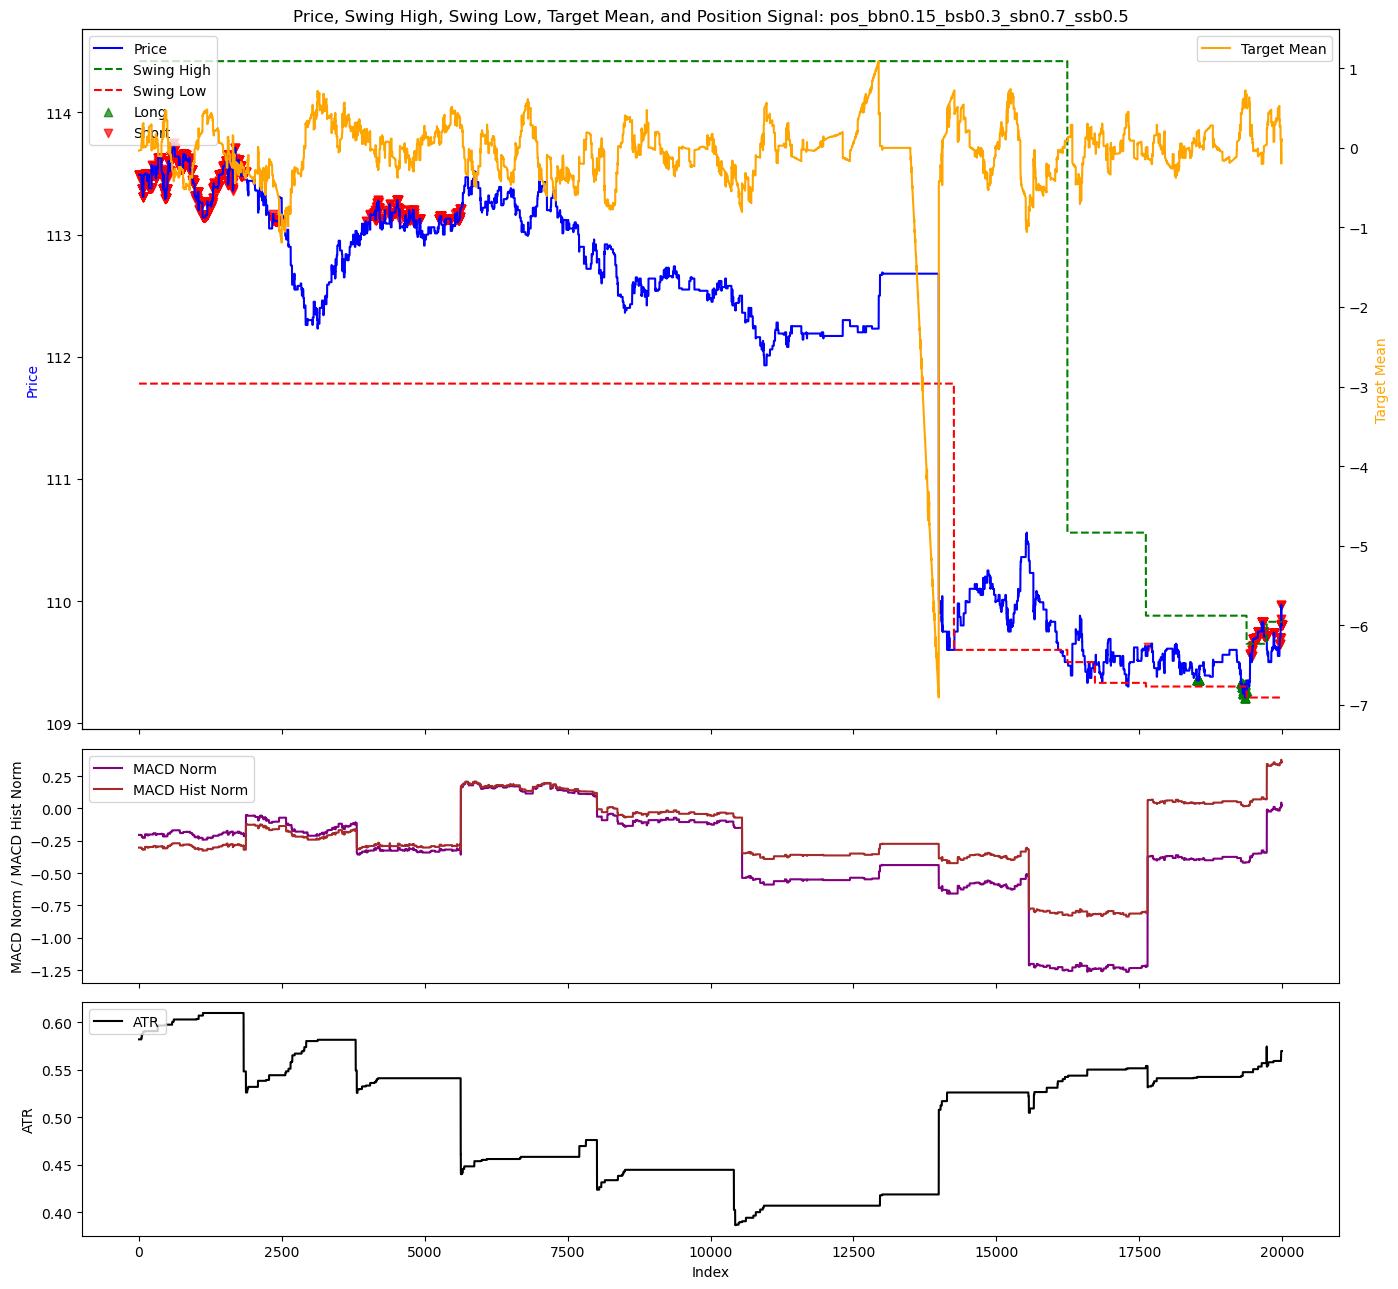

In [36]:
import matplotlib.pyplot as plt

# Option to set length of df to plot
plot_len = 20000  # Set this to desired number of rows to plot

# Get all position signal columns (those starting with 'pos_bbn')
pos_cols = [col for col in df_signals.columns if col.startswith('pos_bbn')]

for col in pos_cols[:1]:
    fig, (ax1, ax3, ax4) = plt.subplots(3, 1, figsize=(14, 13), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
    ax2 = ax1.twinx()
    idx = df_signals.index[:plot_len]
    # Main chart: price, swing_high, swing_low, target_mean, position signals
    ax1.plot(idx, df_signals['price'].iloc[:plot_len], color='blue', label='Price')
    ax1.plot(idx, df_signals['swing_high'].iloc[:plot_len], color='green', linestyle='--', label='Swing High')
    ax1.plot(idx, df_signals['swing_low'].iloc[:plot_len], color='red', linestyle='--', label='Swing Low')
    ax2.plot(idx, df_signals['target_mean'].iloc[:plot_len], color='orange', label='Target Mean')
    ax1.set_ylabel('Price', color='blue')
    ax2.set_ylabel('Target Mean', color='orange')
    # Overlay position signal as points on the price chart
    pos_signal = df_signals[col].iloc[:plot_len]
    long_idx = idx[pos_signal == 1]
    short_idx = idx[pos_signal == -1]
    ax1.scatter(long_idx, df_signals.loc[long_idx, 'price'], color='green', marker='^', label='Long', alpha=0.7)
    ax1.scatter(short_idx, df_signals.loc[short_idx, 'price'], color='red', marker='v', label='Short', alpha=0.7)
    ax1.set_title(f'Price, Swing High, Swing Low, Target Mean, and Position Signal: {col}')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    # Second chart: macd_norm and macd_hist_norm
    ax3.plot(idx, df_signals['macd_norm'].iloc[:plot_len], color='purple', label='MACD Norm')
    ax3.plot(idx, df_signals['macd_hist_norm'].iloc[:plot_len], color='brown', label='MACD Hist Norm')
    ax3.set_ylabel('MACD Norm / MACD Hist Norm')
    ax3.legend(loc='upper left')
    # Third chart: ATR
    ax4.plot(idx, df_signals['atr'].iloc[:plot_len], color='black', label='ATR')
    ax4.set_xlabel('Index')
    ax4.set_ylabel('ATR')
    ax4.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


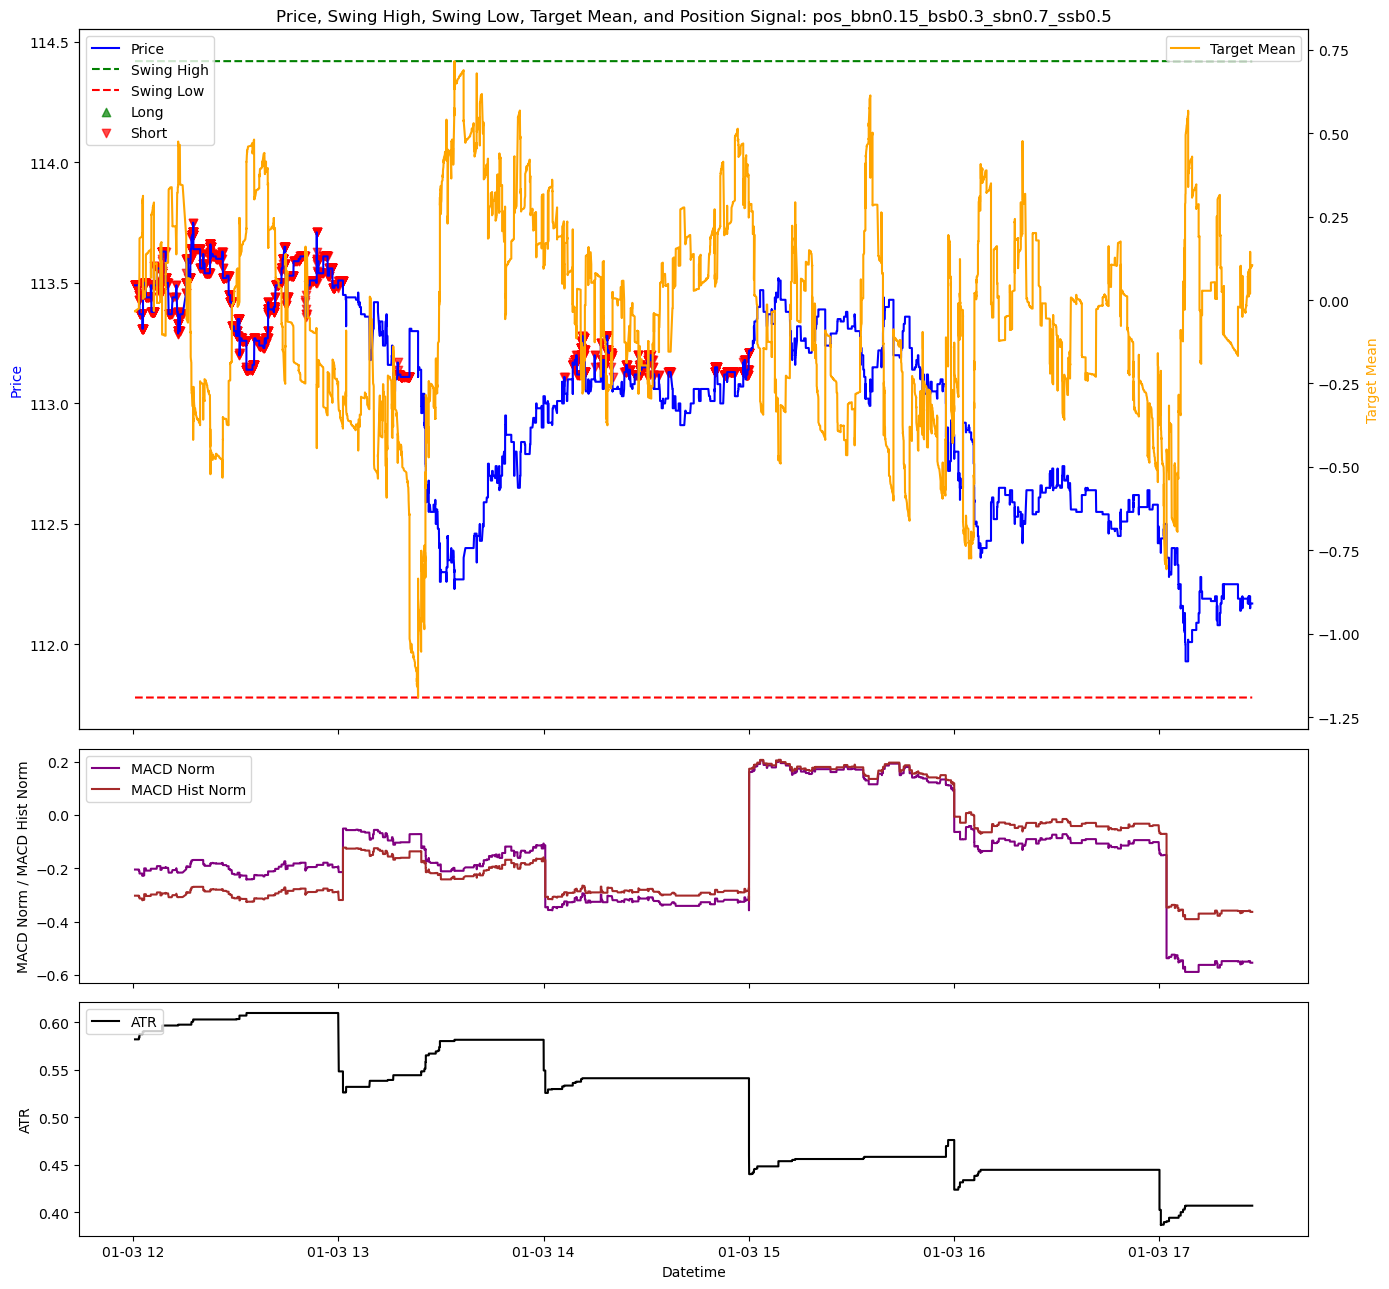

In [38]:
import matplotlib.pyplot as plt

# Option to set length of df to plot
plot_len = 12000  # Set this to desired number of rows to plot

# Get all position signal columns (those starting with 'pos_bbn')
pos_cols = [col for col in df_signals.columns if col.startswith('pos_bbn')]

for col in pos_cols[:1]:
    # Filter out rows with missing datetime or any plotted value
    plot_df = df_signals[['datetime', 'price', 'swing_high', 'swing_low', 'target_mean', 'macd_norm', 'macd_hist_norm', 'atr', col]].iloc[:plot_len].dropna()
    x = plot_df['datetime']
    fig, (ax1, ax3, ax4) = plt.subplots(3, 1, figsize=(14, 13), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
    ax2 = ax1.twinx()
    # Main chart: price, swing_high, swing_low, target_mean, position signals
    ax1.plot(x, plot_df['price'], color='blue', label='Price')
    ax1.plot(x, plot_df['swing_high'], color='green', linestyle='--', label='Swing High')
    ax1.plot(x, plot_df['swing_low'], color='red', linestyle='--', label='Swing Low')
    ax2.plot(x, plot_df['target_mean'], color='orange', label='Target Mean')
    ax1.set_ylabel('Price', color='blue')
    ax2.set_ylabel('Target Mean', color='orange')
    # Overlay position signal as points on the price chart
    pos_signal = plot_df[col]
    long_idx = pos_signal == 1
    short_idx = pos_signal == -1
    ax1.scatter(x[long_idx], plot_df['price'][long_idx], color='green', marker='^', label='Long', alpha=0.7)
    ax1.scatter(x[short_idx], plot_df['price'][short_idx], color='red', marker='v', label='Short', alpha=0.7)
    ax1.set_title(f'Price, Swing High, Swing Low, Target Mean, and Position Signal: {col}')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    # Second chart: macd_norm and macd_hist_norm
    ax3.plot(x, plot_df['macd_norm'], color='purple', label='MACD Norm')
    ax3.plot(x, plot_df['macd_hist_norm'], color='brown', label='MACD Hist Norm')
    ax3.set_ylabel('MACD Norm / MACD Hist Norm')
    ax3.legend(loc='upper left')
    # Third chart: ATR
    ax4.plot(x, plot_df['atr'], color='black', label='ATR')
    ax4.set_xlabel('Datetime')
    ax4.set_ylabel('ATR')
    ax4.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
